[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Curs%2003/problem_of_points.ipynb)

# The Problem of Points: Probability and Fair Division
This notebook explores the **Problem of Points**, a foundational problem in probability theory, solved by **Blaise Pascal** and **Pierre de Fermat** in 1654. The problem considers how to fairly divide the stake of an interrupted game where one player is ahead.

We will examine:
- The **mathematical formulation** of the problem
- **Pascal's method** of counting all possible outcomes
- **Fermat's method** of direct combinatorial calculation
- **Python implementations** to compute fair division
- **Visualizations** illustrating probability changes
- The **historical impact** on probability and finance

## Mathematical Formulation
If a fair game is interrupted, the question is: **how should the stake be fairly divided?**

Let:
- $A$ and $B$ be two players.
- $s$ be the total stake.
- $n_A$ and $n_B$ be the current number of wins for each player.
- $N$ be the total number of wins needed to claim the stake.
- $r_A = N - n_A$ be the remaining wins needed by $A$.
- $r_B = N - n_B$ be the remaining wins needed by $B$.

**Pascal's Method:**
We count the total number of possible sequences of future games and determine how many favor player $A$ winning.

The probability of $A$ winning is computed as:
$$ P(A 	ext{ wins}) = \frac{ \sum_{i=r_A}^{r_A + r_B - 1} C(i, r_A) }{ 2^{(r_A + r_B - 1)} } $$

**Fermat's Method:**
Fermat reasoned that we can sum the probabilities of $A$ winning in exactly $r$ games:
$$ P(A 	ext{ wins}) = \sum_{r=r_A}^{r_A + r_B - 1} C(r-1, r_A-1) \times \left( \frac{1}{2} \right)^r $$

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
def binomial_coefficient(n, k):
    """
    Compute the binomial coefficient C(n, k) = n! / (k! * (n-k)!)
    """
    return math.factorial(n) / (math.factorial(k) * math.factorial(n - k))

In [5]:
def pascal_method(a_wins, b_wins, target_wins, stake):
    a_needs = target_wins - a_wins
    b_needs = target_wins - b_wins
    
    if a_needs <= 0:
        return (stake, 0)
    elif b_needs <= 0:
        return (0, stake)
    
    max_games = a_needs + b_needs - 1
    ways_a_can_win = sum(binomial_coefficient(i, a_needs) for i in range(a_needs, max_games + 1))
    total_possibilities = 2 ** max_games
    a_win_probability = ways_a_can_win / total_possibilities
    return (stake * a_win_probability, stake * (1 - a_win_probability))

In [6]:
def fermat_method(a_wins, b_wins, target_wins, stake):
    a_needs = target_wins - a_wins
    b_needs = target_wins - b_wins
    
    if a_needs <= 0:
        return (stake, 0)
    elif b_needs <= 0:
        return (0, stake)
    
    a_probability = sum(binomial_coefficient(r-1, a_needs-1) * (0.5 ** r) for r in range(a_needs, a_needs + b_needs))
    return (stake * a_probability, stake * (1 - a_probability))

In [7]:
def visualize_fair_division_heatmap(target_wins=5, stake=100):
    a_wins_range = range(0, target_wins)
    b_wins_range = range(0, target_wins)
    results = np.zeros((len(a_wins_range), len(b_wins_range)))
    
    for i, a in enumerate(a_wins_range):
        for j, b in enumerate(b_wins_range):
            results[i, j] = pascal_method(a, b, target_wins, stake)[0] / stake * 100
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(results, annot=True, fmt='.1f', cmap='Blues', xticklabels=b_wins_range, yticklabels=a_wins_range)
    plt.xlabel('Player B Wins')
    plt.ylabel('Player A Wins')
    plt.title('Fair Division Heatmap: Player A Share (%)')
    plt.show()

## Historical Significance
The Problem of Points was crucial in the development of **probability theory**. It led to:
- The **foundation of combinatorial probability**
- The **expected value concept**, used in risk management
- Applications in **modern finance**, such as option pricing and portfolio optimization
The principles here extend to financial risk estimation and probabilistic forecasting.

Pascal Method: (62.5, 37.5)
Fermat Method: (68.75, 31.25)


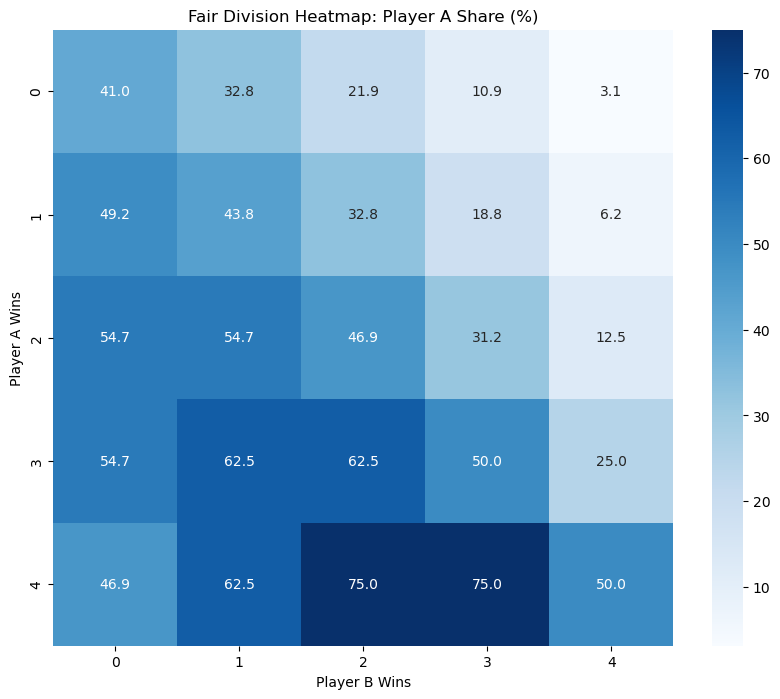

In [9]:
# Example Calculation
a_wins, b_wins, target_wins, stake = 3, 2, 5, 100
print('Pascal Method:', pascal_method(a_wins, b_wins, target_wins, stake))
print('Fermat Method:', fermat_method(a_wins, b_wins, target_wins, stake))

# Visualization
visualize_fair_division_heatmap(target_wins, stake)